# Facial Keypoint Detection NaimishNet

Entrena NaimishNet (modelo ganador de la competición de Kaggle) y lo compara con la Baseline CNN.

**Experimentos que hace este notebook:**
1. NaimishNet con 50k frames (mismos datos que la baseline — comparativa justa de arquitectura)
2. NaimishNet con 100k frames (más datos — comparativa de datos)
3. Tabla comparativa final: Baseline 50k vs NaimishNet 50k vs NaimishNet 100k


## 1. Imports

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

try:
    import torch_directml
    device = torch_directml.device()
    print(f'Usando DirectML (AMD GPU): {device}')
except ImportError:
    device = torch.device('cpu')
    print('Usando CPU.')


Usando DirectML (AMD GPU): privateuseone:0


## 2. Configuración

In [2]:
# Ajustamos la ruta donde estan ubicados los archivos
DATA_DIR = r'F:\DL_Project\Data'

IMAGES_50K      = os.path.join(DATA_DIR, 'preprocessed', 'images_50k.npy')
KEYPOINTS_50K   = os.path.join(DATA_DIR, 'preprocessed', 'keypoints_50k.npy')
IMAGES_100K     = os.path.join(DATA_DIR, 'preprocessed', 'images_100k.npy')
KEYPOINTS_100K  = os.path.join(DATA_DIR, 'preprocessed', 'keypoints_100k.npy')

MODEL_NAIMISH_50K  = os.path.join(DATA_DIR, 'naimishnet_50k.pth')
MODEL_NAIMISH_100K = os.path.join(DATA_DIR, 'naimishnet_100k.pth')
LOSSES_NAIMISH_50K  = os.path.join(DATA_DIR, 'losses_naimish_50k.pkl')
LOSSES_NAIMISH_100K = os.path.join(DATA_DIR, 'losses_naimish_100k.pkl')

IMG_SIZE    = 96
BATCH_SIZE  = 64
NUM_EPOCHS  = 20
LR          = 1e-3
SEED        = 42

print(f'IMG_SIZE:   {IMG_SIZE}')
print(f'BATCH_SIZE: {BATCH_SIZE}')
print(f'NUM_EPOCHS: {NUM_EPOCHS}')


IMG_SIZE:   96
BATCH_SIZE: 64
NUM_EPOCHS: 20


## 3. Dataset

In [3]:
class FacialKeypointDataset(Dataset):

    def __init__(self, images, keypoints):
        self.images    = images   
        self.keypoints = torch.tensor(np.array(keypoints), dtype=torch.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.tensor(np.array(self.images[idx]), dtype=torch.float32)
        return img, self.keypoints[idx]


def make_loaders(images_path, keypoints_path, seed=SEED):

    size_gb = os.path.getsize(images_path) / 1e9
    if size_gb > 4.0:
        # Archivo grande: usar mmap para no consumir RAM
        print(f'Archivo grande ({size_gb:.1f} GB) usando mmap_mode')
        images    = np.load(images_path,    mmap_mode='r')
        keypoints = np.load(keypoints_path, mmap_mode='r')
    else:
        # Archivo pequeño: cargar todo en RAM
        images    = np.load(images_path)
        keypoints = np.load(keypoints_path)

    print(f'Cargado: {os.path.basename(images_path)}  {images.shape}')

    full_dataset = FacialKeypointDataset(images, keypoints)
    torch.manual_seed(seed)
    train_size    = int(0.8 * len(full_dataset))
    val_size      = len(full_dataset) - train_size
    train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    print(f'  Train: {len(train_ds):,}  Val: {len(val_ds):,}')
    return train_loader, val_loader, train_ds, val_ds


## 4. Arquitectura — NaimishNet

Diferencias respecto a la Baseline CNN:
- Activación **ELU** en vez de ReLU
- **BatchNorm2d** después de cada capa conv
- **Dropout progresivo** (0.1 → 0.2 → 0.3 → 0.4 en bloques conv, 0.5 en FC)
- Sin Sigmoid en la salida


In [4]:
class NaimishNet(nn.Module):
    """
    Adaptación de NaimishNet para 68 keypoints.
    Entrada:  (B, 3, 96, 96)
    Salida:   (B, 136)
    """
    def __init__(self, num_keypoints=68):
        super().__init__()
        out_dim = num_keypoints * 2

        self.features = nn.Sequential(
            
            nn.Conv2d(3,  32, kernel_size=4),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.1),

            
            nn.Conv2d(32, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            
            nn.Conv2d(64, 128, kernel_size=2),
            nn.BatchNorm2d(128),
            nn.ELU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),

            
            nn.Conv2d(128, 256, kernel_size=1),
            nn.BatchNorm2d(256),
            nn.ELU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.4),
        )

        
        with torch.no_grad():
            dummy   = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            flat_sz = self.features(dummy).view(1, -1).shape[1]

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_sz, 1000),
            nn.ELU(),
            nn.Dropout(0.5),
            nn.Linear(1000, 1000),
            nn.ELU(),
            nn.Dropout(0.5),
            nn.Linear(1000, out_dim),
        )

    def forward(self, x):
        return self.regressor(self.features(x))



model_test = NaimishNet().to(device)
total_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'Parámetros entrenables NaimishNet: {total_params:,}')

with torch.no_grad():
    dummy = torch.zeros(4, 3, IMG_SIZE, IMG_SIZE).to(device)
    out   = model_test(dummy)
    print(f'Input: {dummy.shape}  →  Output: {out.shape}  (esperado: [4, 136])')
del model_test


Parámetros entrenables NaimishNet: 7,625,080
Input: torch.Size([4, 3, 96, 96])  →  Output: torch.Size([4, 136])  (esperado: [4, 136])


c:\Users\manic\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\torch\nn\functional.py:1593: UserWarning: The operator 'aten::elu.out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  result = torch._C._nn.elu(input, alpha)


## 5. Función de entrenamiento

In [5]:
def train_model(model, train_loader, val_loader, train_ds, val_ds,
                model_path, losses_path, num_epochs=NUM_EPOCHS, lr=LR):
    "Entrena el modelo y guarda el mejor checkpoint y las losses."
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    best_val_loss = float('inf')
    train_losses, val_losses = [], []

    for epoch in range(1, num_epochs + 1):

        # Train
        model.train()
        running_loss = 0.0
        for imgs, kps in train_loader:
            imgs, kps = imgs.to(device), kps.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), kps)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_ds)

        # Validation
        model.eval()
        running_val = 0.0
        with torch.no_grad():
            for imgs, kps in val_loader:
                imgs, kps = imgs.to(device), kps.to(device)
                running_val += criterion(model(imgs), kps).item() * imgs.size(0)
        val_loss = running_val / len(val_ds)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), model_path)
            saved = 'saved'
        else:
            saved = ''

        print(f'Epoch {epoch:2d}/{num_epochs}  '
              f'train: {train_loss:.6f}  val: {val_loss:.6f}  '
              f'lr: {current_lr:.2e}{saved}')

    with open(losses_path, 'wb') as f:
        pickle.dump({'train': train_losses, 'val': val_losses}, f)

    print(f'\nMejor val_loss: {best_val_loss:.6f}')
    print(f'Modelo: {model_path}')
    return train_losses, val_losses, best_val_loss


def compute_rmse(model, loader, device, img_size=IMG_SIZE):
    model.eval()
    all_gt, all_pred = [], []
    with torch.no_grad():
        for imgs, kps in loader:
            imgs = imgs.to(device)
            preds = model(imgs).cpu().numpy()
            all_gt.append(kps.numpy())
            all_pred.append(preds)
    all_gt   = np.concatenate(all_gt,   axis=0) * img_size
    all_pred = np.concatenate(all_pred, axis=0) * img_size
    diff     = (all_gt - all_pred).reshape(-1, 68, 2)
    dist_px  = np.sqrt((diff ** 2).sum(axis=2))
    return dist_px.mean()


---
## 6. Experimento 1 NaimishNet con 50k frames

Mismos datos que la baseline para comparar solo la arquitectura.


In [6]:
print('Experimento 1: NaimishNet 50k \n')
train_loader_50k, val_loader_50k, train_ds_50k, val_ds_50k = make_loaders(IMAGES_50K, KEYPOINTS_50K)

model_50k = NaimishNet().to(device)
losses_train_50k, losses_val_50k, best_50k = train_model(
    model_50k, train_loader_50k, val_loader_50k,
    train_ds_50k, val_ds_50k,
    MODEL_NAIMISH_50K, LOSSES_NAIMISH_50K, lr=LR
)


Experimento 1: NaimishNet 50k 

Archivo grande (5.5 GB) usando mmap_mode
Cargado: images_50k.npy  (50000, 3, 96, 96)
  Train: 40,000  Val: 10,000


KeyboardInterrupt: 

### RMSE NaimishNet 50k

In [11]:
model_50k.load_state_dict(torch.load(MODEL_NAIMISH_50K, map_location='cpu'))
model_50k = model_50k.to(device)
rmse_naimish_50k = compute_rmse(model_50k, val_loader_50k, device)
print(f'RMSE NaimishNet 50k (val): {rmse_naimish_50k:.2f} px')


C:\Users\manic\AppData\Local\Temp\ipykernel_17024\488514245.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_50k.load_state_dict(torch.load(MODEL_NAIMISH_50K, map_l

RMSE NaimishNet 50k (val): 3.15 px


---
## 7. Experimento 2 — NaimishNet con 100k frames

Más datos + mejor arquitectura.


In [ ]:
import os
assert os.path.exists(IMAGES_100K), f'No encontrado: {IMAGES_100K} ejecuta preprocess_100k.ipynb primero'

print('Experimento 2: NaimishNet 100k\n')
train_loader_100k, val_loader_100k, train_ds_100k, val_ds_100k = make_loaders(IMAGES_100K, KEYPOINTS_100K)

model_100k = NaimishNet().to(device)
losses_train_100k, losses_val_100k, best_100k = train_model(
    model_100k, train_loader_100k, val_loader_100k,
    train_ds_100k, val_ds_100k,
    MODEL_NAIMISH_100K, LOSSES_NAIMISH_100K
)


=== Experimento 2: NaimishNet 100k ===

Archivo grande (11.1 GB) — usando mmap_mode
Cargado: images_100k.npy  (100000, 3, 96, 96)
  Train: 80,000  Val: 20,000
Epoch  1/20  train: 0.026147  val: 0.002406  lr: 1.00e-03  ✅
Epoch  2/20  train: 0.002902  val: 0.005565  lr: 1.00e-03
Epoch  3/20  train: 0.002956  val: 0.002176  lr: 1.00e-03  ✅
Epoch  4/20  train: 0.003118  val: 0.002124  lr: 1.00e-03  ✅
Epoch  5/20  train: 0.003138  val: 0.001260  lr: 1.00e-03  ✅
Epoch  6/20  train: 0.003034  val: 0.003184  lr: 1.00e-03
Epoch  7/20  train: 0.002809  val: 0.002024  lr: 1.00e-03
Epoch  8/20  train: 0.002559  val: 0.001610  lr: 1.00e-03
Epoch  9/20  train: 0.002551  val: 0.001029  lr: 1.00e-03  ✅
Epoch 10/20  train: 0.003008  val: 0.006384  lr: 1.00e-03
Epoch 11/20  train: 0.003569  val: 0.001029  lr: 1.00e-03  ✅
Epoch 12/20  train: 0.001716  val: 0.001092  lr: 1.00e-03
Epoch 13/20  train: 0.001792  val: 0.000902  lr: 1.00e-03  ✅
Epoch 14/20  train: 0.001613  val: 0.000737  lr: 1.00e-03  ✅
Epoch

### RMSE NaimishNet 100k

In [7]:
model_100k.load_state_dict(torch.load(MODEL_NAIMISH_100K, map_location='cpu'))
model_100k = model_100k.to(device)
rmse_naimish_100k = compute_rmse(model_100k, val_loader_100k, device)
print(f'RMSE NaimishNet 100k (val): {rmse_naimish_100k:.2f} px')


C:\Users\manic\AppData\Local\Temp\ipykernel_15212\2439435246.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_100k.load_state_dict(torch.load(MODEL_NAIMISH_100K, ma

RMSE NaimishNet 100k (val): 2.36 px


---
## 8. Comparativa final: Baseline vs NaimishNet


In [ ]:
import pickle

# Recrear loaders desde los .npy
train_loader_50k, val_loader_50k, train_ds_50k, val_ds_50k = make_loaders(IMAGES_50K, KEYPOINTS_50K)
train_loader_100k, val_loader_100k, train_ds_100k, val_ds_100k = make_loaders(IMAGES_100K, KEYPOINTS_100K)

# Cargar losses desde disco
with open(LOSSES_NAIMISH_50K, 'rb') as f:
    losses_50k = pickle.load(f)
with open(LOSSES_NAIMISH_100K, 'rb') as f:
    losses_100k = pickle.load(f)
with open(os.path.join(DATA_DIR, 'training_losses.pkl'), 'rb') as f:
    losses_baseline = pickle.load(f)

best_50k  = min(losses_50k['val'])
best_100k = min(losses_100k['val'])

# Cargar modelos desde disco
model_50k  = NaimishNet().to(device)
model_50k.load_state_dict(torch.load(MODEL_NAIMISH_50K,  map_location='cpu'))
model_50k  = model_50k.to(device)

model_100k = NaimishNet().to(device)
model_100k.load_state_dict(torch.load(MODEL_NAIMISH_100K, map_location='cpu'))
model_100k = model_100k.to(device)

# Calcular RMSE
rmse_naimish_50k  = compute_rmse(model_50k,  val_loader_50k,  device)
rmse_naimish_100k = compute_rmse(model_100k, val_loader_100k, device)
rmse_baseline_50k = 0.89

# Tabla comparativa 
print('=' * 65)
print(f'{"Modelo":<30} {"Frames":<10} {"Mejor val MSE":<16} {"RMSE (px)"}')
print('-' * 65)
print(f'{"Baseline CNN":<30} {"50k":<10} {"0.000065":<16} {rmse_baseline_50k:.2f} px')
print(f'{"NaimishNet":<30} {"50k":<10} {best_50k:<16.6f} {rmse_naimish_50k:.2f} px')
print(f'{"NaimishNet":<30} {"100k":<10} {best_100k:<16.6f} {rmse_naimish_100k:.2f} px')
print('=' * 65)

mejora_arq  = (rmse_baseline_50k - rmse_naimish_50k)  / rmse_baseline_50k * 100
mejora_data = (rmse_baseline_50k - rmse_naimish_100k) / rmse_baseline_50k * 100
print(f'\nMejora por arquitectura (NaimishNet 50k vs Baseline 50k): {mejora_arq:+.1f}%')
print(f'Mejora total (NaimishNet 100k vs Baseline 50k):           {mejora_data:+.1f}%')

Archivo grande (5.5 GB) — usando mmap_mode
Cargado: images_50k.npy  (50000, 3, 96, 96)
  Train: 40,000  Val: 10,000
Archivo grande (11.1 GB) — usando mmap_mode
Cargado: images_100k.npy  (100000, 3, 96, 96)
  Train: 80,000  Val: 20,000


C:\Users\manic\AppData\Local\Temp\ipykernel_15212\3441418147.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_50k.load_state_dict(torch.load(MODEL_NAIMISH_50K,  ma

Modelo                         Frames     Mejor val MSE    RMSE (px)
-----------------------------------------------------------------
Baseline CNN                   50k        0.000065         0.89 px
NaimishNet                     50k        0.000802         3.15 px
NaimishNet                     100k       0.000510         2.36 px

Mejora por arquitectura (NaimishNet 50k vs Baseline 50k): -253.5%
Mejora total (NaimishNet 100k vs Baseline 50k):           -165.3%


## 9. Curvas de pérdida comparativas

In [ ]:
import pickle

# Recrear loaders desde los .npy
train_loader_50k, val_loader_50k, train_ds_50k, val_ds_50k = make_loaders(IMAGES_50K, KEYPOINTS_50K)
train_loader_100k, val_loader_100k, train_ds_100k, val_ds_100k = make_loaders(IMAGES_100K, KEYPOINTS_100K)

# Cargar losses desde disco
with open(LOSSES_NAIMISH_50K, 'rb') as f:
    losses_50k = pickle.load(f)
with open(LOSSES_NAIMISH_100K, 'rb') as f:
    losses_100k = pickle.load(f)
with open(os.path.join(DATA_DIR, 'training_losses.pkl'), 'rb') as f:
    losses_baseline = pickle.load(f)

best_50k  = min(losses_50k['val'])
best_100k = min(losses_100k['val'])

# Cargar modelos desde disco
model_50k  = NaimishNet().to(device)
model_50k.load_state_dict(torch.load(MODEL_NAIMISH_50K,  map_location='cpu'))
model_50k  = model_50k.to(device)

model_100k = NaimishNet().to(device)
model_100k.load_state_dict(torch.load(MODEL_NAIMISH_100K, map_location='cpu'))
model_100k = model_100k.to(device)

# Calcular RMSE
rmse_naimish_50k  = compute_rmse(model_50k,  val_loader_50k,  device)
rmse_naimish_100k = compute_rmse(model_100k, val_loader_100k, device)
rmse_baseline_50k = 0.89

# Tabla comparativa
print('=' * 65)
print(f'{"Modelo":<30} {"Frames":<10} {"Mejor val MSE":<16} {"RMSE (px)"}')
print('-' * 65)
print(f'{"Baseline CNN":<30} {"50k":<10} {"0.000065":<16} {rmse_baseline_50k:.2f} px')
print(f'{"NaimishNet":<30} {"50k":<10} {best_50k:<16.6f} {rmse_naimish_50k:.2f} px')
print(f'{"NaimishNet":<30} {"100k":<10} {best_100k:<16.6f} {rmse_naimish_100k:.2f} px')
print('=' * 65)

mejora_arq  = (rmse_baseline_50k - rmse_naimish_50k)  / rmse_baseline_50k * 100
mejora_data = (rmse_baseline_50k - rmse_naimish_100k) / rmse_baseline_50k * 100
print(f'\nMejora por arquitectura (NaimishNet 50k vs Baseline 50k): {mejora_arq:+.1f}%')
print(f'Mejora total (NaimishNet 100k vs Baseline 50k):           {mejora_data:+.1f}%')

Archivo grande (5.5 GB) — usando mmap_mode
Cargado: images_50k.npy  (50000, 3, 96, 96)
  Train: 40,000  Val: 10,000
Archivo grande (11.1 GB) — usando mmap_mode
Cargado: images_100k.npy  (100000, 3, 96, 96)
  Train: 80,000  Val: 20,000


C:\Users\manic\AppData\Local\Temp\ipykernel_15212\3441418147.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_50k.load_state_dict(torch.load(MODEL_NAIMISH_50K,  ma

Modelo                         Frames     Mejor val MSE    RMSE (px)
-----------------------------------------------------------------
Baseline CNN                   50k        0.000065         0.89 px
NaimishNet                     50k        0.000802         3.15 px
NaimishNet                     100k       0.000510         2.36 px

Mejora por arquitectura (NaimishNet 50k vs Baseline 50k): -253.5%
Mejora total (NaimishNet 100k vs Baseline 50k):           -165.3%


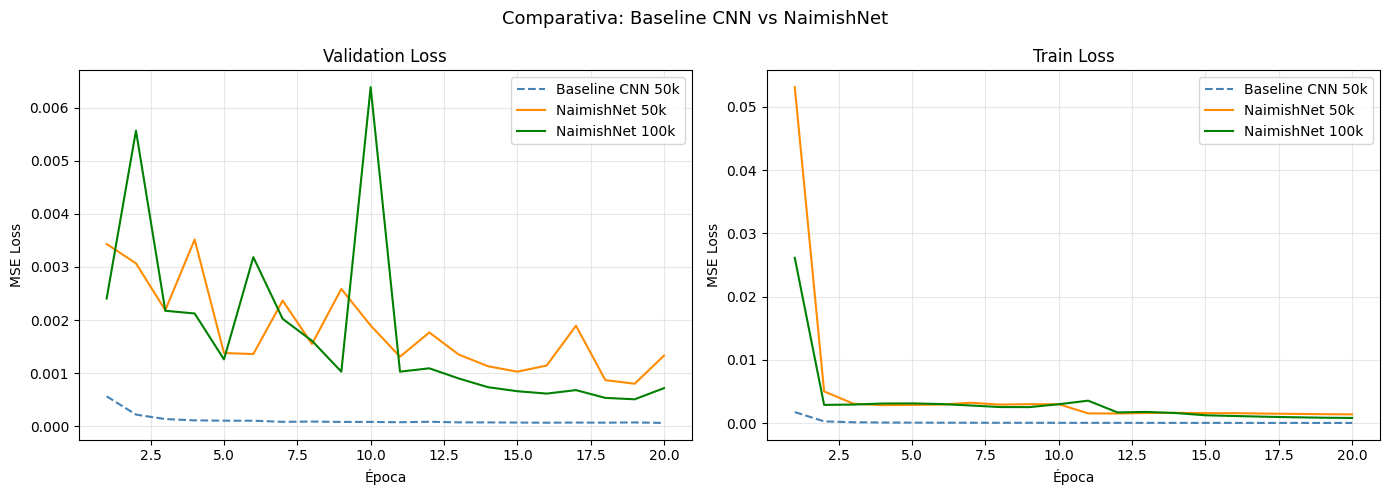

In [17]:
# Cargar todas las losses desde disco
with open(os.path.join(DATA_DIR, 'training_losses.pkl'), 'rb') as f:
    losses_baseline = pickle.load(f)
with open(LOSSES_NAIMISH_50K, 'rb') as f:
    losses_50k = pickle.load(f)
with open(LOSSES_NAIMISH_100K, 'rb') as f:
    losses_100k = pickle.load(f)

epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Val loss de los tres modelos
axes[0].plot(epochs, losses_baseline['val'],  label='Baseline CNN 50k',  color='steelblue',  linestyle='--')
axes[0].plot(epochs, losses_50k['val'],       label='NaimishNet 50k',     color='darkorange')
axes[0].plot(epochs, losses_100k['val'],      label='NaimishNet 100k',    color='green')
axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Train loss de los tres modelos
axes[1].plot(epochs, losses_baseline['train'], label='Baseline CNN 50k', color='steelblue',  linestyle='--')
axes[1].plot(epochs, losses_50k['train'],      label='NaimishNet 50k',    color='darkorange')
axes[1].plot(epochs, losses_100k['train'],     label='NaimishNet 100k',   color='green')
axes[1].set_title('Train Loss')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('MSE Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Comparativa: Baseline CNN vs NaimishNet', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Predicciones visuales — NaimishNet 100k

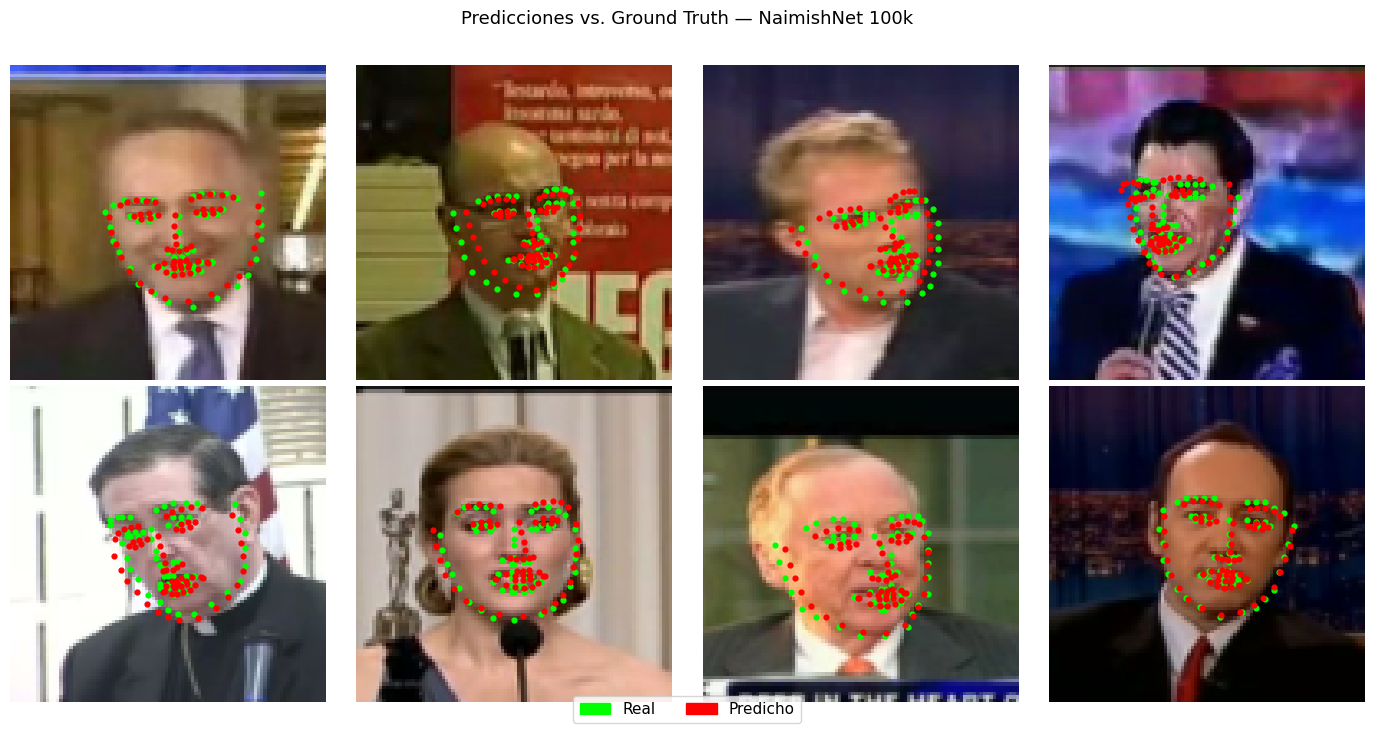

In [ ]:
model_100k.eval()
imgs_b, kps_b = next(iter(val_loader_100k))
imgs_b = imgs_b.to(device)

with torch.no_grad():
    preds_b = model_100k(imgs_b)

# Desnormalizar predicciones de NaimishNet
preds_np = preds_b.cpu().numpy()
preds_np = np.clip(preds_np, 0, 1)

imgs_np  = imgs_b.cpu().numpy()[:8]
kps_gt   = kps_b.numpy()[:8]
kps_pred = preds_np[:8]

cols = 4
fig, axes = plt.subplots(2, cols, figsize=(cols * 3.5, 7))
axes = axes.flatten()

for i in range(8):
    img  = imgs_np[i].transpose(1, 2, 0)
    gt   = kps_gt[i].reshape(-1, 2)   * IMG_SIZE
    pred = kps_pred[i].reshape(-1, 2) * IMG_SIZE

    axes[i].imshow(img)
    axes[i].scatter(gt[:, 0],   gt[:, 1],   s=12, c='lime', zorder=5)
    axes[i].scatter(pred[:, 0], pred[:, 1], s=12, c='red',  zorder=6)
    axes[i].axis('off')

patch_gt   = mpatches.Patch(color='lime', label='Real')
patch_pred = mpatches.Patch(color='red',  label='Predicho')
fig.legend(handles=[patch_gt, patch_pred], loc='lower center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Predicciones vs. Ground Truth — NaimishNet 100k', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
print('Experimento 3: NaimishNet 50k con lr = 1e-4\n')
train_loader_50k, val_loader_50k, train_ds_50k, val_ds_50k = make_loaders(IMAGES_50K, KEYPOINTS_50K)

model_50k = NaimishNet().to(device)
losses_train_50k, losses_val_50k, best_50k = train_model(
    model_50k, train_loader_50k, val_loader_50k,
    train_ds_50k, val_ds_50k,
    MODEL_NAIMISH_50K, LOSSES_NAIMISH_50K, lr=1e-4
)


=== Experimento 1: NaimishNet 50k ===

Archivo grande (5.5 GB) — usando mmap_mode
Cargado: images_50k.npy  (50000, 3, 96, 96)
  Train: 40,000  Val: 10,000
Epoch  1/20  train: 0.044983  val: 0.005743  lr: 1.00e-04  ✅
Epoch  2/20  train: 0.014293  val: 0.003511  lr: 1.00e-04  ✅
Epoch  3/20  train: 0.008330  val: 0.004506  lr: 1.00e-04
Epoch  4/20  train: 0.005127  val: 0.002920  lr: 1.00e-04  ✅
Epoch  5/20  train: 0.003315  val: 0.002130  lr: 1.00e-04  ✅
Epoch  6/20  train: 0.002444  val: 0.001629  lr: 1.00e-04  ✅
Epoch  7/20  train: 0.002130  val: 0.001262  lr: 1.00e-04  ✅
Epoch  8/20  train: 0.001885  val: 0.001202  lr: 1.00e-04  ✅
Epoch  9/20  train: 0.001734  val: 0.001007  lr: 1.00e-04  ✅
Epoch 10/20  train: 0.001586  val: 0.000853  lr: 1.00e-04  ✅
Epoch 11/20  train: 0.001493  val: 0.000919  lr: 1.00e-04
Epoch 12/20  train: 0.001378  val: 0.000652  lr: 1.00e-04  ✅
Epoch 13/20  train: 0.001317  val: 0.000621  lr: 1.00e-04  ✅
Epoch 14/20  train: 0.001245  val: 0.000636  lr: 1.00e-04


In [ ]:
model_50k.load_state_dict(torch.load(MODEL_NAIMISH_50K, map_location='cpu'))
model_50k = model_50k.to(device)
rmse_naimish_50k = compute_rmse(model_50k, val_loader_50k, device)
print(f'RMSE NaimishNet 50k_lr4 (val): {rmse_naimish_50k:.2f} px')


C:\Users\manic\AppData\Local\Temp\ipykernel_5568\488514245.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_50k.load_state_dict(torch.load(MODEL_NAIMISH_50K, map_lo

RMSE NaimishNet 50k (val): 2.26 px


In [ ]:
import os
assert os.path.exists(IMAGES_100K), f'No encontrado: {IMAGES_100K} ejecuta preprocess_100k.ipynb primero'

print('Experimento 4: NaimishNet 100k con lr=1e-4\n')
train_loader_100k, val_loader_100k, train_ds_100k, val_ds_100k = make_loaders(IMAGES_100K, KEYPOINTS_100K)

model_100k = NaimishNet().to(device)
losses_train_100k, losses_val_100k, best_100k = train_model(
    model_100k, train_loader_100k, val_loader_100k,
    train_ds_100k, val_ds_100k,
    MODEL_NAIMISH_100K, LOSSES_NAIMISH_100K, lr=1e-4
)


=== Experimento 2: NaimishNet 100k ===

Archivo grande (11.1 GB) — usando mmap_mode
Cargado: images_100k.npy  (100000, 3, 96, 96)
  Train: 80,000  Val: 20,000
Epoch  1/20  train: 0.030695  val: 0.003809  lr: 1.00e-04  ✅
Epoch  2/20  train: 0.006233  val: 0.003507  lr: 1.00e-04  ✅
Epoch  3/20  train: 0.002652  val: 0.001490  lr: 1.00e-04  ✅
Epoch  4/20  train: 0.001906  val: 0.001021  lr: 1.00e-04  ✅
Epoch  5/20  train: 0.001627  val: 0.000873  lr: 1.00e-04  ✅
Epoch  6/20  train: 0.001411  val: 0.000991  lr: 1.00e-04
Epoch  7/20  train: 0.001273  val: 0.000609  lr: 1.00e-04  ✅
Epoch  8/20  train: 0.001154  val: 0.000552  lr: 1.00e-04  ✅
Epoch  9/20  train: 0.001070  val: 0.000428  lr: 1.00e-04  ✅
Epoch 10/20  train: 0.001007  val: 0.000435  lr: 1.00e-04
Epoch 11/20  train: 0.000943  val: 0.000374  lr: 1.00e-04  ✅
Epoch 12/20  train: 0.000895  val: 0.000365  lr: 1.00e-04  ✅
Epoch 13/20  train: 0.000852  val: 0.000276  lr: 1.00e-04  ✅
Epoch 14/20  train: 0.000819  val: 0.000335  lr: 1.00e

In [ ]:
model_100k.load_state_dict(torch.load(MODEL_NAIMISH_100K, map_location='cpu'))
model_100k = model_100k.to(device)
rmse_naimish_100k = compute_rmse(model_100k, val_loader_100k, device)
print(f'RMSE NaimishNet 100k_lr4 (val): {rmse_naimish_100k:.2f} px')


C:\Users\manic\AppData\Local\Temp\ipykernel_17024\2439435246.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_100k.load_state_dict(torch.load(MODEL_NAIMISH_100K, ma

RMSE NaimishNet 100k (val): 1.64 px
